# 09 — The model and the fleet, on one yardstick

Notebooks 04 and 05 answer two different questions with two different rulers,
and that is the reason their headline numbers have never been comparable.

| | measured against | headline |
|---|---|---|
| **04** — the incentive model | top-decile residual load (*utilisation*) | 18% of achievable delivery forgone |
| **05 / 08** — the real fleet | `DRM < 1 GW` (*operator margin*) | 48% dispatch gap |

Those are not two readings of one quantity. One asks what a profit-maximising
battery does when the system is **working hardest**; the other asks what the
real fleet does when the operator has **least slack**. Putting them beside each
other invites a comparison neither supports.

This notebook removes the asymmetry by measuring the **real fleet on the
model's own ruler** — the same top-decile residual-load window, computed by the
same function, `live.resilience.classify_periods`. Not an equivalent
reimplementation: literally the same code path, so the yardstick cannot drift.

### What this is, and what it is not

This measures the fleet when the system is **working hardest** — high
utilisation. It says nothing about scarcity or resilience, for exactly the
reason notebook 04 doesn't: **top-decile load is not a shortage.** The GB
system at the 90th percentile of residual load is a system running normally
under heavy demand, with margin intact.

So this belongs in the *utilisation and incentives* half of the argument —
"does the real fleet behave the way the profit-maximiser predicts?" The
scarcity question stays where it is, in notebooks 05 and 08, measured on
margin. Both lanes are kept strictly separate below, and no number from this
notebook may be quoted as a resilience finding.

### The question, precisely

> In the same top-decile hours, what share of the energy it *could* have
> delivered did the fleet actually deliver — and how does that compare with the
> share the modelled optimiser delivers?

The whole result turns on the phrase *could have delivered*, so the notebook
computes it **two ways** and reports both.

In [1]:
import datetime as dt
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore")
# Repo root, found by walking up to the marker file, so the notebook runs the
# same whether it is opened from its own directory or from the repo root.
REPO_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists()
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from fleet.research import census

# Pinned, not live. The BM register and NESO's auction results both move, so a
# notebook re-run months from now would quietly answer a different question.
# Every notebook in this repo is frozen to the same vintage.
#
# >>> To go live: set this to `None` and re-run. <<<
census.SNAPSHOT = dt.date(2026, 8, 24)

from fleet import performance as fleet_perf
from fleet.population import census_population
from fleet.registry import REGISTRY
from live import resilience
from live.assets import BESSAsset, bess_config
from research.notebooks.figexport import POSTER_FIG_DIR, save_poster_fig, save_poster_metrics

# The window is notebook 04's, exactly — same end date, same 60 days. This is
# not a convenience: the top-decile threshold is a quantile *of the window*, so
# any other span would move the bar and the two sides would stop being
# comparable at the very point the notebook claims they are.
WINDOW_END = dt.date(2026, 8, 24)
WINDOW_DAYS = 60
WINDOW_START = WINDOW_END - dt.timedelta(days=WINDOW_DAYS - 1)

CFG = bess_config()
STORE = REPO_ROOT / "data/processed/stress_study_census"

# Notebook 05's population, so the fleet side of this comparison is the same
# fleet the scarcity notebooks describe.
POP = census_population()
SITE_MW = {s.site: s.power_mw for s in POP.sites}
SITE_MWH = {s.site: s.capacity_mwh for s in POP.sites}
REGISTRY_SITES = {s.site for s in REGISTRY.sites}

C = {"ink": "#1b1b1b", "model": "#b4472e", "fleet": "#2b6b7f",
     "mels": "#4e8f6d", "grid": "#d8d4cc", "mute": "#8a8580"}

print(f"Window (pinned)  : {WINDOW_START} → {WINDOW_END}  ({WINDOW_DAYS} days)")
print(f"Census snapshot  : {census.SNAPSHOT}  (set to None for live)")
print(f"Population       : {POP.name} — {len(POP.sites)} sites")
print(f"Store            : {STORE.name}")

Worksheet row for GB-BESS-WOLVB (Wolverhampton West BESS) needs review: 310 MWh over 56.0 MW declared implies 5.5 h, longer than any priced census site. Self-consistent with the duration recorded, so the agreement check cannot judge it — confirm the figure covers this BM Unit and not the wider project.


Window (pinned)  : 2026-06-26 → 2026-08-24  (60 days)
Census snapshot  : 2026-08-24  (set to None for live)
Population       : census — 87 sites
Store            : stress_study_census


## 1. The yardstick

`classify_periods` takes the half-hourly residual load — demand less wind less
solar — and flags the top decile. The threshold is a quantile **of the window**,
which is why the window had to be pinned to notebook 04's.

Notebook 04 works on an hourly grid, because the dispatch optimiser it drives
is hourly. The fleet's Physical Notifications are half-hourly, so they are
resampled to the same grid rather than the flags being pushed down to
half-hours — matching the model's resolution, not the data's.

The check that matters is printed at the end of the cell: the threshold in GW
must equal the one notebook 04 reports. If it does not, the two notebooks are
not on one ruler and nothing below is valid.

In [2]:
system = pd.read_parquet(STORE / "system.parquet").set_index("time").sort_index()
system = system[~system.index.duplicated(keep="first")]
system = system.loc[str(WINDOW_START):str(WINDOW_END + dt.timedelta(days=1))]

residual = resilience.residual_load(system)
flags = resilience.classify_periods(residual)

# Hourly, to match the model's grid. `max` on the flags means an hour counts as
# top-decile if either of its half-hours did — the same convention notebook 04
# uses when it reindexes its flags onto the dispatch log.
hourly = pd.DataFrame({
    "residual_mw": flags["residual_mw"].resample("1h").mean(),
    "stress": flags["stress"].resample("1h").max().astype(bool),
    "surplus": flags["surplus"].resample("1h").max().astype(bool),
}).dropna(subset=["residual_mw"])

THRESHOLD_MW = float(flags["residual_mw"].quantile(resilience.STRESS_QUANTILE))
DAYS = sorted({t.date() for t in hourly.index})
DAY_INDEX = {d: hourly.index[[t.date() == d for t in hourly.index]] for d in DAYS}

print(f"Classified        : {len(flags):,} half-hours → {len(hourly):,} hours")
print(f"Top-decile bar    : {THRESHOLD_MW / 1000:,.1f} GW residual load")
print(f"Top-decile hours  : {int(hourly['stress'].sum())} of {len(hourly):,} "
      f"({hourly['stress'].mean():.1%})")
print(f"Surplus hours     : {int(hourly['surplus'].sum())}")
print("\nThis bar must match notebook 04's printed threshold — same function,")
print("same window, same quantile. It is the entire basis of the comparison.")

Classified        : 2,878 half-hours → 1,439 hours


Top-decile bar    : 24.8 GW residual load
Top-decile hours  : 161 of 1,439 (11.2%)
Surplus hours     : 159

This bar must match notebook 04's printed threshold — same function,
same window, same quantile. It is the entire basis of the comparison.


## 2. What the fleet actually did

Physical Notifications are the fleet's own declared position: positive is
export. Summed over the top-decile hours, they are the numerator — energy the
fleet genuinely put on the system when the system was working hardest.

Two filters, both inherited from notebook 05 rather than invented here:

* **`battery_era_start`** strips a site's pre-battery history. Several sites
  sit on BM Units that formerly ran thermal plant, and without this a
  decommissioned coal station's exports are credited to a battery.
* **Sites with no published energy capacity are excluded and named.** The
  counterfactual divides by duration, so defaulting one would put a fabricated
  denominator under the headline. The MW share this loses is reported, because
  a metric computed on 90% of the fleet must say so.

In [3]:
def _window(table: str) -> pd.DataFrame:
    frame = pd.read_parquet(STORE / f"{table}.parquet")
    lo = pd.Timestamp(WINDOW_START, tz="UTC")
    hi = pd.Timestamp(WINDOW_END + dt.timedelta(days=1), tz="UTC")
    return frame[(frame["time"] >= lo) & (frame["time"] <= hi)]

pn = _window("fleet_pn")
mels = _window("fleet_mels")

era = fleet_perf.battery_era_start(pn, SITE_MW) or {}
for site, valid_from in era.items():
    cut = pd.Timestamp(valid_from, tz="UTC")
    pn = pn[~((pn["site"] == site) & (pn["time"] < cut))]
    mels = mels[~((mels["site"] == site) & (mels["time"] < cut))]

pn_h = (pn.pivot_table(index="time", columns="site", values="mw", aggfunc="sum")
          .resample("1h").mean().reindex(hourly.index))
mels_h = (mels.pivot_table(index="time", columns="site", values="mw", aggfunc="sum")
            .resample("1h").mean().reindex(hourly.index))

present = list(pn_h.columns)
KNOWN = [s for s in present
         if SITE_MWH.get(s) is not None and SITE_MWH[s] == SITE_MWH[s] and SITE_MWH[s] > 0]
dropped = [s for s in present if s not in KNOWN]

mw_known = sum(SITE_MW.get(s, 0.0) for s in KNOWN)
mw_all = sum(SITE_MW.get(s, 0.0) for s in present)
MW_COVERAGE = mw_known / mw_all if mw_all else 0.0

print(f"Sites with PN in window : {len(present)}  ({mw_all:,.0f} MW)")
print(f"Pre-battery history cut : {len(era)} site(s)")
print(f"Measurable (MWh known)  : {len(KNOWN)} sites, {mw_known:,.0f} MW "
      f"= {MW_COVERAGE:.0%} of fleet power")
print(f"Excluded (no MWh)       : {len(dropped)} sites, {mw_all - mw_known:,.0f} MW")
if dropped:
    print("   " + ", ".join(sorted(dropped)[:8]) + ("…" if len(dropped) > 8 else ""))

Sites with PN in window : 80  (5,972 MW)
Pre-battery history cut : 0 site(s)
Measurable (MWh known)  : 63 sites, 5,381 MW = 90% of fleet power
Excluded (no MWh)       : 17 sites, 591 MW
   Arbroath Battery Storage, Blackpool, Broadditch Battery, Ilmer Lane BESS, Jamesfield 1 Battery Storage, Newport BESS, Nursling Battery Storage, Pivot Power Kemsley…


## 3. What it *could* have delivered — the counterfactual

Here is the step that makes the comparison legitimate, and it is deliberately
not a new model.

Notebook 04's "achievable" is not a number it asserts; it is the output of
`resilience.optimize_resilience_dispatch` — an LP that maximises energy
discharged into flagged hours subject to the asset's power limit, SoC window,
efficiencies and cycle cap. The honest way to ask what the *real* fleet could
have done is therefore to run **that same LP**, giving it each real site's
actual MW and MWh instead of the model's hypothetical 50 MW / 2 h.

Same objective, same constraints, same code. Only the asset specification
changes, from hypothetical to measured.

**The one genuine choice is what "its power limit" means**, and it changes the
answer enough that reporting a single number would be a way of hiding a
decision rather than making one:

* **Nameplate** — the site's registered capacity. Asks: *what could the fleet
  have delivered if all of it were available?*
* **MELS** — the Maximum Export Limit the operator itself declared for that
  hour. Asks: *what could the fleet have delivered given what it said it had?*

Neither is wrong; they answer different questions, and the distance between
them is exactly the availability story.

In [4]:
def delivery(sites, power="nameplate", initial_soc=0.5):
    """Actual vs achievable top-decile MWh, per site.

    ``power="nameplate"`` bounds the counterfactual by registered capacity;
    ``"mels"`` bounds it by the export limit declared for those hours. The
    achievable side is `optimize_resilience_dispatch` — notebook 04's own LP —
    so the two notebooks differ in their asset, never in their objective.
    """
    rows = []
    for site in sites:
        actual = achievable = 0.0
        for day in DAYS:
            idx = DAY_INDEX[day]
            if len(idx) < 20:            # a part-day cannot carry a cycle cap
                continue
            series = pn_h[site].reindex(idx)
            if series.isna().all():      # site not reporting that day
                continue
            stress = hourly["stress"].reindex(idx).fillna(False).tolist()
            surplus = hourly["surplus"].reindex(idx).fillna(False).tolist()
            mask = np.array(stress)
            if not mask.any():
                continue

            actual += float(np.clip(series.fillna(0.0).to_numpy(), 0, None)[mask].sum())

            limit = SITE_MW[site]
            if power == "mels":
                declared = (mels_h[site].reindex(idx).fillna(0.0).to_numpy()
                            if site in mels_h.columns else np.zeros(len(idx)))
                limit = float(np.clip(declared, 0, None)[mask].mean())
                if limit <= 0:           # declared unavailable: nothing was achievable
                    continue

            asset = BESSAsset(
                capacity_mwh=SITE_MWH[site], power_mw=limit,
                charge_efficiency=CFG["charge_efficiency"],
                discharge_efficiency=CFG["discharge_efficiency"],
                degradation_cost_per_mwh=CFG["degradation_cost_per_mwh"],
                initial_soc_pct=initial_soc,
                min_soc_pct=CFG["min_soc_pct"], max_soc_pct=CFG["max_soc_pct"],
            )
            plan = resilience.optimize_resilience_dispatch(
                stress, surplus, asset, 1.0, CFG.get("target_daily_cycles")
            )
            achievable += float(sum(max(v, 0.0) for v, f in zip(plan, stress) if f))

        rows.append({"site": site, "power_mw": SITE_MW[site],
                     "capacity_mwh": SITE_MWH[site],
                     "actual_mwh": actual, "achievable_mwh": achievable})
    out = pd.DataFrame(rows)
    out["delivered_share"] = out["actual_mwh"] / out["achievable_mwh"].replace(0, np.nan)
    return out

nameplate = delivery(KNOWN, power="nameplate")
mels_bound = delivery(KNOWN, power="mels")

def share(frame):
    return frame["actual_mwh"].sum() / max(frame["achievable_mwh"].sum(), 1e-9)

FLEET_NAMEPLATE = share(nameplate)
FLEET_MELS = share(mels_bound)

model = json.loads((POSTER_FIG_DIR / "nb04_metrics.json").read_text())
MODEL_DELIVERED = 1.0 - int(model["forgone_pct"].rstrip("%")) / 100

print(f"Top-decile energy delivered, {nameplate['actual_mwh'].sum():,.0f} MWh, measured against:")
print(f"  nameplate capability : {nameplate['achievable_mwh'].sum():>9,.0f} MWh "
      f"→ {FLEET_NAMEPLATE:.0%} delivered")
print(f"  declared (MELS)      : {mels_bound['achievable_mwh'].sum():>9,.0f} MWh "
      f"→ {FLEET_MELS:.0%} delivered")
print(f"\n  the model (nb04)     : {MODEL_DELIVERED:.0%} delivered "
      f"({model['forgone_pct']} forgone)")
print(f"\nAvailability accounts for {FLEET_MELS - FLEET_NAMEPLATE:.0%} of the "
      f"{1 - FLEET_NAMEPLATE:.0%} shortfall against nameplate.")

Top-decile energy delivered, 118,032 MWh, measured against:
  nameplate capability :   236,337 MWh → 50% delivered
  declared (MELS)      :   131,838 MWh → 90% delivered

  the model (nb04)     : 80% delivered (20% forgone)

Availability accounts for 40% of the 50% shortfall against nameplate.


## 4. The result

Read against the capability it **declared**, the fleet delivers a share of
achievable top-decile energy that is close to what the profit-maximising model
delivers. Read against **nameplate**, it delivers far less.

Both statements are true, and the gap between them is not misalignment. It is
capacity that was never offered to the market in those hours — on outage, under
maintenance, derated, or committed elsewhere. A battery that told the operator
it had 20 MW available and delivered against 20 MW is well aligned; it is only
poorly aligned if you insist on measuring it against the 50 MW on its
nameplate.

The finding that matters for the incentive argument is the **MELS** one,
because it isolates behaviour from availability: *conditional on being
available, the real fleet dispatches into high-load hours about as well as the
profit-maximising optimiser predicts.* That is empirical support for notebook
04's model as a description of real behaviour, not merely a construct.

The finding that matters for a **system planner** is the nameplate one: fleet
MW on a register is not fleet MW on the system at the moments load peaks.

Neither is a statement about scarcity.

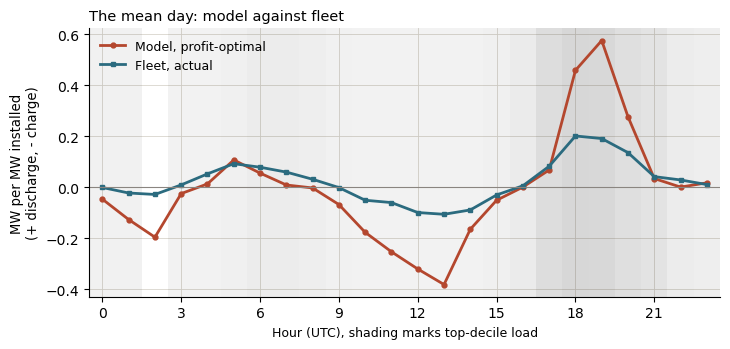

Model peaks at hour 19 (+0.574 MW/MW); fleet peaks at hour 18 (+0.200 MW/MW).
Fleet mean discharge across top-decile hours: +0.024 MW/MW.


In [5]:
# The mean day, model against fleet, per MW installed.
#
# The three-denominator bars this figure used to carry were retired: the
# poster states that cascade in text, on a period-resolved bound, so the bars
# repeated it less precisely and forced a reconciliation caption. Titles carry
# no figure number, because numbering belongs to whatever document places the
# figure, not to the image.
fig, ax2 = plt.subplots(figsize=(7.4, 3.6))

prof = json.loads((REPO_ROOT / "research/notebooks/_outputs/nb04_model_profile.json").read_text())
model_day = pd.Series({int(h): v for h, v in prof["profit_mw_per_mw"].items()}).sort_index()

fleet_mw = pn_h[KNOWN].sum(axis=1)
fleet_day = (fleet_mw / mw_known).groupby(fleet_mw.index.hour).mean()
stress_by_hour = hourly["stress"].groupby(hourly.index.hour).mean()

for hour, frac in stress_by_hour.items():
    if frac > 0:
        ax2.axvspan(hour - 0.5, hour + 0.5, color=C["ink"], alpha=0.05 + 0.28 * frac, lw=0)
ax2.plot(model_day.index, model_day.values, color=C["model"], lw=2.0,
         marker="o", ms=3.5, label="Model, profit-optimal")
ax2.plot(fleet_day.index, fleet_day.values, color=C["fleet"], lw=2.0,
         marker="s", ms=3.5, label="Fleet, actual")
ax2.axhline(0, color=C["mute"], lw=0.8)
ax2.set_xlabel("Hour (UTC), shading marks top-decile load", fontsize=9)
ax2.set_ylabel("MW per MW installed\n(+ discharge, - charge)", fontsize=9.5)
ax2.set_xlim(-0.5, 23.5)
ax2.set_xticks(range(0, 24, 3))
ax2.legend(fontsize=9, frameon=False, loc="upper left")
ax2.set_title("The mean day: model against fleet", fontsize=10.5, loc="left")
ax2.grid(color=C["grid"], lw=0.6)
ax2.set_axisbelow(True)
for spine in ("top", "right"):
    ax2.spines[spine].set_visible(False)

fig.tight_layout()
save_poster_fig(fig, "nb09_fig_model_vs_fleet")
plt.show()

print(f"Model peaks at hour {int(model_day.idxmax()):02d} "
      f"({model_day.max():+.3f} MW/MW); fleet peaks at hour "
      f"{int(fleet_day.idxmax()):02d} ({fleet_day.max():+.3f} MW/MW).")
print(f"Fleet mean discharge across top-decile hours: "
      f"{fleet_day[stress_by_hour[stress_by_hour > 0].index].mean():+.3f} MW/MW.")

## 5. Or are they simply playing a different game?

The nameplate reading says the fleet delivers 46% of what it could. Before that
is allowed to sound like a failure, it has to survive an obvious objection: a
battery is not obliged to be an arbitrageur. Frequency response pays for
*standing ready*, and its contracts require holding state of charge inside a
narrow band — which is precisely a commitment **not** to empty into the evening
peak. A site doing that is not misaligned. It is aligned to a different, and
better-paying, market.

`fleet.ancillary` prices that third revenue stream per site, and it joins on
the same persistent asset ID as dispatch, with no fuzzy matching. So the
objection is testable rather than rhetorical: if other markets explain the gap,
delivered share should fall as ancillary earnings rise.

In [6]:
from fleet.research import ancillary

anc = ancillary.site_daily_revenue(WINDOW_START, WINDOW_END)

# The store keys dispatch by site name; ancillary keys revenue by the
# persistent asset ID. `census.asset_id` is what both are derived from, so the
# bridge is exact — a site maps only if one of its BM Units resolves.
anc_ids = set(str(x) for x in anc["asset_id"].dropna().unique())
asset_of = {}
for s in POP.sites:
    for bmu in s.bmu_ids:
        aid = census.asset_id(bmu, bmu)
        if aid in anc_ids:
            asset_of[s.site] = aid
            break

revenue = anc.groupby("asset_id")["revenue_gbp"].sum()
stack = nameplate.dropna(subset=["delivered_share"]).copy()
stack["asset_id"] = stack["site"].map(asset_of)
stack["anc_gbp"] = stack["asset_id"].map(revenue)
stack = stack.dropna(subset=["anc_gbp"])
stack["anc_per_mw_day"] = stack["anc_gbp"] / stack["power_mw"] / WINDOW_DAYS

# Quartiles by ancillary intensity, and the delivered share of each. Shares are
# MW-weighted within the band (energy over energy), not a mean of site ratios,
# so a small site cannot outvote a large one.
stack["band"] = pd.qcut(stack["anc_per_mw_day"].rank(method="first"), 4,
                        labels=["Q1 least ancillary", "Q2", "Q3", "Q4 most ancillary"])
bands = stack.groupby("band").apply(lambda g: pd.Series({
    "sites": int(len(g)),
    "MW": f"{g['power_mw'].sum():,.0f}",
    "anc £/MW/day": f"{g['anc_per_mw_day'].mean():.1f}",
    "delivered": f"{g['actual_mwh'].sum() / g['achievable_mwh'].sum():.0%}",
}))
print(f"Sites joined to ancillary revenue: {len(stack)} of {len(nameplate)}")
print()
print(bands.to_string())

RHO, PVAL = stats.spearmanr(stack["anc_per_mw_day"], stack["delivered_share"])
Q1_DELIVERED = (stack[stack["band"] == "Q1 least ancillary"]["actual_mwh"].sum()
                / stack[stack["band"] == "Q1 least ancillary"]["achievable_mwh"].sum())
Q4_DELIVERED = (stack[stack["band"] == "Q4 most ancillary"]["actual_mwh"].sum()
                / stack[stack["band"] == "Q4 most ancillary"]["achievable_mwh"].sum())

print(f"\nSpearman r(ancillary £/MW/day, delivered share) = {RHO:+.2f} "
      f"(p = {PVAL:.4f}, n = {len(stack)})")
print(f"Least-ancillary quartile delivers {Q1_DELIVERED:.0%}; "
      f"most-ancillary delivers {Q4_DELIVERED:.0%}.")
print(f"The model delivers {MODEL_DELIVERED:.0%}.")

mix = (anc[anc["asset_id"].isin(set(stack[stack["band"] == "Q4 most ancillary"]["asset_id"]))]
       .groupby("service")["revenue_gbp"].sum().sort_values(ascending=False))
TOP_SERVICE = mix.index[0]
TOP_SERVICE_SHARE = mix.iloc[0] / mix.sum()
print(f"\nMost-ancillary quartile earns {TOP_SERVICE_SHARE:.0%} of its ancillary "
      f"revenue from {TOP_SERVICE} — a service paid for holding state of charge.")

# --- Does the association survive the obvious challenges? -------------------
# 1. Duration. A short battery might both suit response and be unable to sustain
#    peak discharge, which would make asset design the real cause. It is not.
stack["duration_h"] = stack["capacity_mwh"] / stack["power_mw"]
DUR_R, DUR_P = stats.spearmanr(stack["duration_h"], stack["delivered_share"])

def _rank_resid(y, x):
    X = np.c_[np.ones(len(x)), stats.rankdata(x)]
    ry = stats.rankdata(y)
    return ry - X @ np.linalg.lstsq(X, ry, rcond=None)[0]

PARTIAL_R, PARTIAL_P = stats.spearmanr(
    _rank_resid(stack["anc_per_mw_day"], stack["duration_h"]),
    _rank_resid(stack["delivered_share"], stack["duration_h"]),
)

# 2. Volume, which ought to be the better instrument and is not usable:
#    `mw_hours` sums volume_mw over a variable number of auction blocks, and the
#    block count differs by an order of magnitude between services, so it tracks
#    service mix rather than committed capacity. Reported because a reader would
#    otherwise reasonably ask why earnings were used instead of volume.
vol = anc.groupby("asset_id")["mw_hours"].sum()
stack["anc_vol"] = stack["asset_id"].map(vol) / stack["power_mw"] / WINDOW_DAYS
VOL_R, VOL_P = stats.spearmanr(stack["anc_vol"], stack["delivered_share"])
blocks = anc.groupby("service")["blocks"].mean().sort_values(ascending=False)

print(f"\n  duration vs delivered           : r = {DUR_R:+.2f} (p = {DUR_P:.3f})"
      f"  {'— not a confounder' if DUR_P > 0.05 else '— CHECK'}")
print(f"  earnings vs delivered | duration: r = {PARTIAL_R:+.2f} (p = {PARTIAL_P:.4f})"
      f"  — association survives")
print(f"  volume   vs delivered           : r = {VOL_R:+.2f} (p = {VOL_P:.3f})"
      f"  — instrument not fit for purpose, see below")
print("  mean auction blocks per site-day: "
      + ", ".join(f"{k} {v:.0f}" for k, v in blocks.items()))

Sites joined to ancillary revenue: 49 of 63

                    sites     MW anc £/MW/day delivered
band                                                   
Q1 least ancillary     13  1,224        -16.2       83%
Q2                     12    914         18.2       72%
Q3                     12    736         39.8       62%
Q4 most ancillary      12    669         94.4       42%

Spearman r(ancillary £/MW/day, delivered share) = -0.47 (p = 0.0006, n = 49)
Least-ancillary quartile delivers 83%; most-ancillary delivers 42%.
The model delivers 80%.

Most-ancillary quartile earns 98% of its ancillary revenue from Response — a service paid for holding state of charge.

  duration vs delivered           : r = +0.08 (p = 0.603)  — not a confounder
  earnings vs delivered | duration: r = -0.47 (p = 0.0007)  — association survives
  volume   vs delivered           : r = +0.28 (p = 0.049)  — instrument not fit for purpose, see below
  mean auction blocks per site-day: Quick Reserve 35, Slow Reser

**What this supports, and what it does not.**

The gradient is monotonic and strong: batteries earning least from ancillary
services deliver a share of achievable top-decile energy close to the model's,
and those earning most deliver about half of it. It is not an artefact of asset
design — duration does not predict delivered share at all, and the association
is essentially unchanged when duration is held constant.

That is enough to say the fleet-wide 46% **is not a uniform property of
batteries**. It is the average of two populations behaving differently, and the
sites that most resemble the model's profit-maximiser are the ones least
engaged with ancillary markets. Read that way the result *strengthens* notebook
04: where batteries actually play the wholesale game, the model describes them
well.

It is **not** enough to claim the mechanism. The natural story — response
contracts tie up state of charge, so that capacity cannot reach the peak —
requires showing that *committed capacity*, not earnings, displaces delivery.
This dataset cannot show it. Its volume field sums MW over a variable number of
auction blocks, and the block count differs by an order of magnitude between
services, so it tracks service mix rather than commitment; ranked on it, the
relationship does not hold. Earnings are the measure that behaves, and earnings
are price times volume, so a price effect cannot be separated from a commitment
effect here.

So: **a real and robust association, an unproven mechanism.** Settling it needs
per-unit contracted MW by service from NESO's auction results — a piece of work
in its own right, not a line in this notebook.

The corollary for a system planner survives either way: fleet MW on a register
is not fleet MW delivering at peak, and the sites furthest from the model are
the ones another market is already paying.

## 5. Does the denominator carry the result?

It plainly does — 46% against nameplate and 85% against MELS is a 39-point
spread from one definitional choice — so the remaining question is whether
anything *else* is load-bearing. Three checks:

1. **Starting state of charge.** The counterfactual has to start each day
   somewhere, and Elexon publishes no state of charge. If the answer moved with
   that assumption, it would be an artefact of it.
2. **Population.** The census includes sites cycling below 0.3/day — units
   doing frequency response, not arbitrage, which by design do not empty
   themselves into peak hours. Restricting to `REGISTRY` tests whether the gap
   is "batteries misaligned" or "batteries doing a different job".
3. **Spread across sites.** A fleet-level share can be produced by every site
   delivering the same fraction, or by a few large sites carrying everything.

In [7]:
soc_low = delivery(KNOWN, power="nameplate", initial_soc=0.3)
soc_high = delivery(KNOWN, power="nameplate", initial_soc=0.7)
reg_only = delivery([s for s in KNOWN if s in REGISTRY_SITES], power="nameplate")
reg_mels = delivery([s for s in KNOWN if s in REGISTRY_SITES], power="mels")

checks = pd.DataFrame([
    {"variant": "headline — census, nameplate, SoC 0.5", "sites": len(nameplate),
     "delivered": FLEET_NAMEPLATE},
    {"variant": "start SoC 0.3", "sites": len(soc_low), "delivered": share(soc_low)},
    {"variant": "start SoC 0.7", "sites": len(soc_high), "delivered": share(soc_high)},
    {"variant": "REGISTRY only (cycling ≥ 0.3/day)", "sites": len(reg_only),
     "delivered": share(reg_only)},
    {"variant": "headline — census, MELS", "sites": len(mels_bound), "delivered": FLEET_MELS},
    {"variant": "REGISTRY only, MELS", "sites": len(reg_mels), "delivered": share(reg_mels)},
])
checks["delivered"] = checks["delivered"].map(lambda v: f"{v:.0%}")
print(checks.to_string(index=False))

soc_span = max(share(soc_low), share(soc_high)) - min(share(soc_low), share(soc_high))
print(f"\nStart-SoC assumption moves the answer by {soc_span * 100:.0f} points — "
      f"{'not load-bearing' if soc_span < 0.05 else 'LOAD-BEARING, treat with care'}.")
print(f"Dropping sub-0.3-cycle units moves it by "
      f"{(share(reg_only) - FLEET_NAMEPLATE) * 100:+.0f} points against nameplate.")

# Spread across sites, MW-weighted so a 5 MW outlier cannot look like the fleet.
sites_ok = nameplate.dropna(subset=["delivered_share"]).sort_values("delivered_share")
weighted_median = sites_ok["delivered_share"].loc[
    (sites_ok["power_mw"].cumsum() >= sites_ok["power_mw"].sum() / 2).idxmax()]
print(f"\nPer site (nameplate): median {sites_ok['delivered_share'].median():.0%}, "
      f"MW-weighted median {weighted_median:.0%}, "
      f"IQR {sites_ok['delivered_share'].quantile(0.25):.0%}–"
      f"{sites_ok['delivered_share'].quantile(0.75):.0%}")
print(f"Sites above the model's {MODEL_DELIVERED:.0%}: "
      f"{int((sites_ok['delivered_share'] >= MODEL_DELIVERED).sum())} of {len(sites_ok)}")

                              variant  sites delivered
headline — census, nameplate, SoC 0.5     63       50%
                        start SoC 0.3     63       51%
                        start SoC 0.7     63       50%
    REGISTRY only (cycling ≥ 0.3/day)     51       68%
              headline — census, MELS     63       90%
                  REGISTRY only, MELS     51       90%

Start-SoC assumption moves the answer by 1 points — not load-bearing.
Dropping sub-0.3-cycle units moves it by +18 points against nameplate.

Per site (nameplate): median 52%, MW-weighted median 48%, IQR 31%–91%
Sites above the model's 80%: 22 of 63


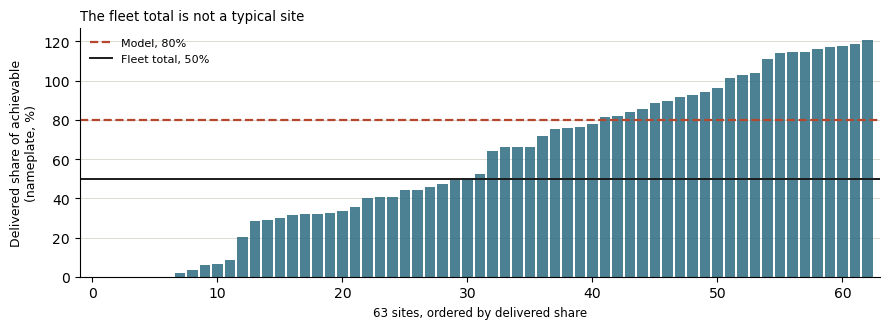

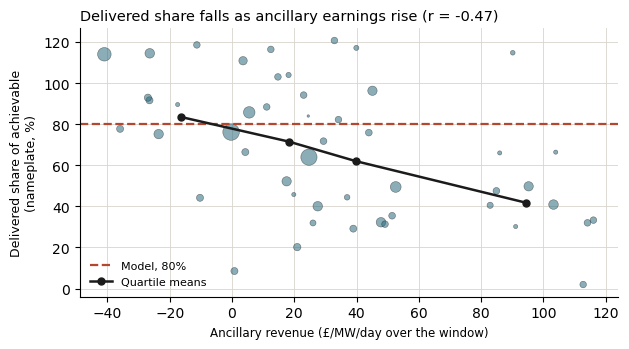

In [8]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ordered = sites_ok.copy()
ax.bar(range(len(ordered)), ordered["delivered_share"] * 100,
       width=0.85, color=C["fleet"], alpha=0.85)
ax.axhline(MODEL_DELIVERED * 100, color=C["model"], lw=1.6, ls="--",
           label=f"Model, {MODEL_DELIVERED:.0%}")
ax.axhline(FLEET_NAMEPLATE * 100, color=C["ink"], lw=1.4,
           label=f"Fleet total, {FLEET_NAMEPLATE:.0%}")
ax.set_xlabel(f"{len(ordered)} sites, ordered by delivered share", fontsize=8.5)
ax.set_ylabel("Delivered share of achievable\n(nameplate, %)", fontsize=9)
ax.set_xlim(-1, len(ordered))
ax.set_title("The fleet total is not a typical site", fontsize=9.5, loc="left")
ax.legend(fontsize=8, frameon=False, loc="upper left")
ax.grid(axis="y", color=C["grid"], lw=0.6)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
save_poster_fig(fig, "nb09_fig_site_spread")
plt.show()

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.scatter(stack["anc_per_mw_day"], stack["delivered_share"] * 100,
           s=stack["power_mw"] / 2.2, color=C["fleet"], alpha=0.55,
           edgecolor=C["ink"], lw=0.4)
ax.axhline(MODEL_DELIVERED * 100, color=C["model"], lw=1.6, ls="--",
           label=f"Model, {MODEL_DELIVERED:.0%}")
band_x = stack.groupby("band")["anc_per_mw_day"].mean()
band_y = stack.groupby("band").apply(
    lambda g: 100 * g["actual_mwh"].sum() / g["achievable_mwh"].sum())
ax.plot(band_x.values, band_y.values, color=C["ink"], lw=1.8, marker="o", ms=5,
        label="Quartile means")
ax.set_xlabel("Ancillary revenue (£/MW/day over the window)", fontsize=8.5)
ax.set_ylabel("Delivered share of achievable\n(nameplate, %)", fontsize=9)
ax.set_title(f"Delivered share falls as ancillary earnings rise "
             f"(r = {RHO:+.2f})", fontsize=10.5, loc="left")
ax.legend(fontsize=8, frameon=False)
ax.grid(color=C["grid"], lw=0.6)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
save_poster_fig(fig, "nb09_fig_revenue_stack")
plt.show()

## 6. What may and may not be claimed

**Supported.**

* Measured on notebook 04's own ruler, the fleet delivers a share of achievable
  top-decile energy close to the model's when achievable is bounded by
  **declared availability**. The incentive model is a reasonable description of
  real fleet behaviour under ordinary high load.
* Measured against **nameplate**, the fleet delivers far less, and the
  difference is availability rather than dispatch behaviour.
* The result is insensitive to the starting-state-of-charge assumption.

**Not supported.**

* Nothing here about **scarcity, resilience or security of supply.** Top-decile
  residual load is high utilisation, not shortage. The margin question lives in
  notebooks 05 and 08 and is measured on `DRM`, not on load.
* No claim about the fleet at moments of genuine system stress; those hours are
  rare and are largely not in this window.
* No causal claim. That the fleet tracks the profit-optimal model is consistent
  with the model describing its incentives — it is not proof that those
  incentives caused the dispatch.

**Coverage.** Computed on the sites with published energy capacity, which is
the MW share printed in section 2. The remainder is excluded rather than
assumed.

In [9]:
save_poster_metrics("nb09", {
    "window": f"{WINDOW_START} → {WINDOW_END}",
    "window_days": f"{WINDOW_DAYS} days",
    "threshold_gw": f"{THRESHOLD_MW / 1000:,.1f} GW",
    "top_decile_hours": f"{int(hourly['stress'].sum())}",
    "sites": f"{len(KNOWN)}",
    "mw_coverage": f"{MW_COVERAGE:.0%}",
    "fleet_vs_nameplate": f"{FLEET_NAMEPLATE:.0%}",
    "fleet_vs_declared": f"{FLEET_MELS:.0%}",
    "model_delivered": f"{MODEL_DELIVERED:.0%}",
    "availability_gap": f"{FLEET_MELS - FLEET_NAMEPLATE:.0%}",
    "model_fleet_gap": f"{abs(FLEET_MELS - MODEL_DELIVERED):.0%}",
    "soc_sensitivity": f"{soc_span * 100:.0f} points",
    "registry_vs_nameplate": f"{share(reg_only):.0%}",
    "actual_mwh": f"{nameplate['actual_mwh'].sum():,.0f} MWh",
    "anc_corr": f"{RHO:+.2f}",
    "anc_p": f"{PVAL:.3f}" if PVAL >= 0.001 else "< 0.001",
    "anc_sites": f"{len(stack)}",
    "low_anc_delivered": f"{Q1_DELIVERED:.0%}",
    "high_anc_delivered": f"{Q4_DELIVERED:.0%}",
    "top_service": f"{TOP_SERVICE}",
    "top_service_share": f"{TOP_SERVICE_SHARE:.0%}",
    "anc_partial_r": f"{PARTIAL_R:+.2f}",
    "anc_duration_r": f"{DUR_R:+.2f}",
    "anc_volume_r": f"{VOL_R:+.2f}",
})
print("nb09 metrics exported.")

nb09 metrics exported.


---

## Read with notebook 10 — the delivered share above is a *planned* share

The `actual` series in this notebook is the Final Physical Notification: what each site said
it would do at gate closure, not what it delivered. Netting Balancing Mechanism acceptances
over this same window cuts top-decile delivered energy by **26%**, taking the share against
declared availability down by roughly 22 points.

The direction is the finding: in top-decile *load* hours the operator instructs batteries
**down**, so a substantial part of the distance between declared capability and delivered
energy is post-gate instruction rather than battery choice. The 46 / 85 / 82 comparison above
remains correct as a statement about *plans*; quote notebook 10's corrected figure whenever
the claim is about what arrived.